# Módulo 06: Plotagem e Visualização
>
> [Universidade Federal do Ceará (UFC)](https://www.ufc.br/)\
> [Departamento de Computação (DC)](https://dc.ufc.br/pt/)\
> [Capacitação Técnica e Empreendedora em IA (CTE-IA)](https://www.cteia.dc.ufc.br/)\
> Fase I: Capacitação Teórica de IA\
> Disciplina: Programação para Ciência de Dados (60h)\
> Professor: [Lincoln S. Rocha](http://lattes.cnpq.br/0656977742590515)\
> E-mail: <lincoln@dc.ufc.br>
>

Criar visualizações informativas (às vezes chamadas de gráficos) é uma das tarefas mais importantes na análise de dados. Pode fazer parte do processo exploratório — por exemplo, para ajudar a identificar outliers ou transformações de dados necessárias, ou como uma forma de gerar ideias para modelos. Para outros, construir uma visualização interativa para a web pode ser o objetivo final. O Python possui muitas bibliotecas complementares para criar visualizações estáticas ou dinâmicas, mas, neste módulo, focaremos principalmente no `matplotlib` e em bibliotecas que se baseiam nele. Este módulo cobrirá o seguinte conteúdo:

1. Introdução à API do `matplotlib`
2. Plotando com Pandas and `seaborn`

## 1. Introdução à API do Matplotlib

### 1.1. Instalando Matplotlib

O método recomendado para instalar o `matplotlib` depende do seu fluxo de trabalho preferido. Abaixo, dividimos os métodos de instalação nas seguintes categorias:

- Baseado em projeto (ex.: uv, pixi) (recomendado para novos usuários)
- Baseado em ambiente (ex.: pip, conda) (o fluxo de trabalho tradicional)
- Gerenciadores de pacotes do sistema (não recomendado para a maioria dos usuários)
- Compilação a partir do código-fonte (para usuários avançados e fins de desenvolvimento)

Escolha o método que melhor se adapta às suas necessidades. Se não tiver certeza, comece com o método baseado em ambiente usando `conda` ou `pip`. No nosso curso usaremos a instalação via `pip`: `uv pip install matplotlib`

Se você já possuir o Matplotlib instalado, podes atualizá-lo da seguinte forma: `uv pip install --upgrade matplotlib`

Após instalar Matplotlib, verifique a instalação executando o seguinte em um shell ou script Python:

In [1]:
import matplotlib

print(matplotlib.__version__)

3.11.2


### 1.2. Visão Geral

Com o `matplotlib`, usamos a seguinte convenção de importação:

In [2]:
import matplotlib.pyplot as plt

Após executar o notebook `%matplotlib` no Jupyter (ou simplesmente `%matplotlib` no IPython), podemos tentar criar um gráfico simples. Se tudo estiver configurado corretamente, um gráfico de linhas como o da figura abaixo deverá aparecer:

In [3]:
%matplotlib inline

In [4]:
import numpy as np

data = np.arange(10)
data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

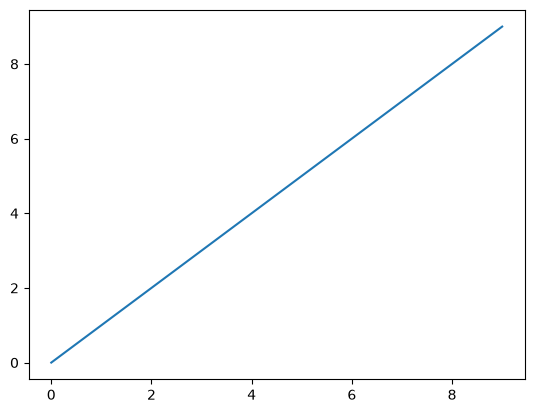

In [ ]:
plt.plot(data);

Embora bibliotecas como o `seaborn` e as funções de plotagem integradas do Pandas lidem com muitos dos detalhes rotineiros da criação de gráficos, caso você queira personalizá-los além das opções de função fornecidas, precisará aprender um pouco sobre a API do `matplotlib`.

### 1.3. Figuras e Subgráficos

Os gráficos no `matplotlib` ficam armazenados em um objeto `Figure`. Você pode criar uma nova figura com `plt.figure`:

In [6]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

No IPython, se você executar primeiro `%matplotlib` para configurar a integração do `matplotlib`, uma janela de plotagem vazia aparecerá, mas no Jupyter nada será exibido até que usemos mais alguns comandos.

A função `plt.figure` possui diversas opções; em particular, `figsize` garante que a figura tenha um tamanho e proporção específicos ao ser salva em disco.

Não é possível criar um gráfico com uma figura em branco. É necessário criar um ou mais subplots usando `add_subplot`.

In [7]:
ax1 = fig.add_subplot(2, 2, 1)

Isso significa que a figura deve ser 2 × 2 (portanto, até quatro gráficos no total) e estamos selecionando o primeiro dos quatro subplots (numerados a partir de 1). Se você criar os dois subplots seguintes, obterá uma visualização semelhante à figura abaixo:

In [8]:
ax2 = fig.add_subplot(2, 2, 2)

In [9]:
ax3 = fig.add_subplot(2, 2, 3)

>
> Nota! Uma peculiaridade do uso de notebooks Jupyter é que os gráficos são redefinidos após a avaliação de cada célula, portanto, você deve colocar todos os comandos de plotagem em uma única célula do notebook.
>

Aqui executamos todos esses comandos na mesma célula:

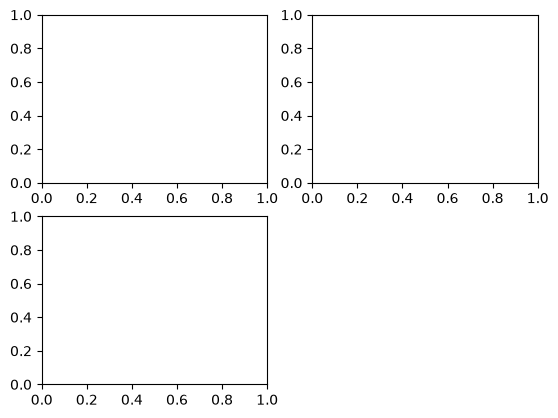

In [10]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

Esses objetos de eixo de plotagem possuem vários métodos que criam diferentes tipos de gráficos, sendo preferível usar os métodos de eixo em vez das funções de plotagem de nível superior, como plt.plot. Por exemplo, podemos criar um gráfico de linhas com o método plot (veja a figura gerada abaixo):

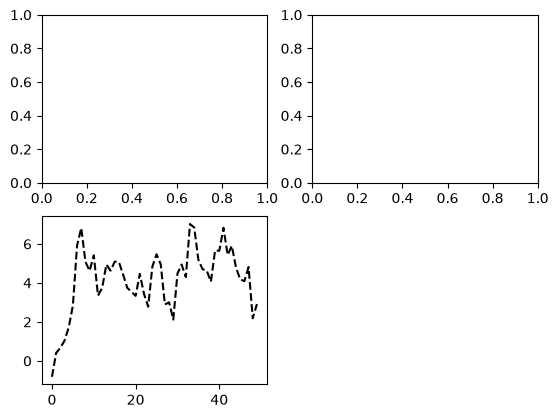

In [11]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

ax3.plot(np.random.standard_normal(50).cumsum(), color='black', linestyle='dashed')

Ao executar este código, você poderá notar uma saída como `<matplotlib.lines.Line2D at ...>`. O `matplotlib` retorna objetos que fazem referência ao subcomponente do gráfico que acabou de ser adicionado. Muitas vezes, você pode ignorar essa saída com segurança ou adicionar um ponto e vírgula (`;`)no final da linha para suprimi-la.

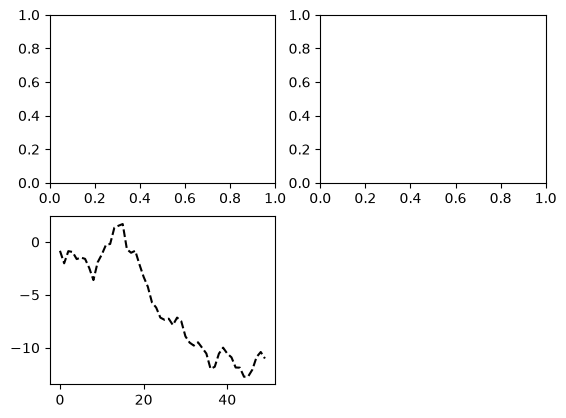

In [12]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

ax3.plot(np.random.standard_normal(50).cumsum(), color='black', linestyle='dashed');

As opções adicionais instruem o `matplotlib` a plotar uma linha tracejada preta. Os objetos retornados por `fig.add_subplot` aqui são objetos `AxesSubplot`, nos quais você pode plotar diretamente nos outros subplots vazios chamando o método de instância de cada um (veja a figura resultante):

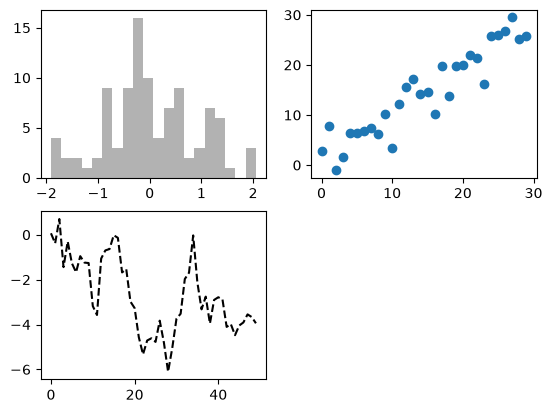

In [13]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

ax1.hist(np.random.standard_normal(100), bins=20, color='black', alpha=0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))
ax3.plot(np.random.standard_normal(50).cumsum(), color='black', linestyle='dashed');

A opção de estilo `alpha=0.3` define a transparência do gráfico sobreposto. Você pode encontrar um catálogo completo de tipos de gráficos na [documentação do `matplotlib`](https://matplotlib.org/).

Para facilitar a criação de uma grade de subplots, o `matplotlib` inclui um método `plt.sub` que cria uma nova figura e retorna um array NumPy contendo os objetos de subplot criados.

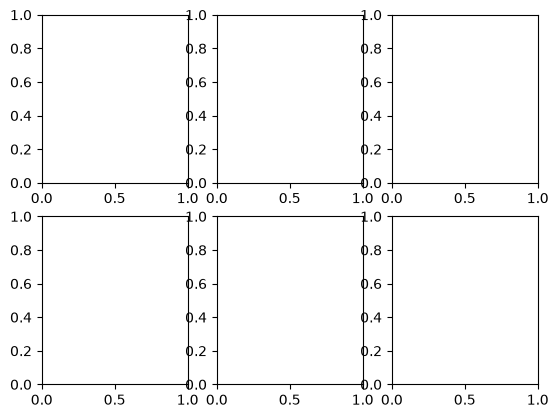

In [14]:
fig, axes = plt.subplots(2, 3)

In [15]:
axes

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

O array de eixos pode então ser indexado como um array bidimensional; por exemplo, `axes[0, 1]` refere-se ao subplot na linha superior, no centro. Você também pode indicar que os subplots devem ter o mesmo eixo `x` ou `y` usando `sharex` e `sharey`, respectivamente. Isso pode ser útil ao comparar dados na mesma escala; caso contrário, o `matplotlib` dimensiona automaticamente os limites do gráfico independentemente. Consulte a tabela abaixo para obter mais informações sobre esse método.

| Argumento | Descrição |
|------------|------------|
| `nrows` | Número de linhas de subgráficos (subplots). |
| `ncols` | Número de colunas de subgráficos (subplots). |
| `sharex` | Define que todos os subgráficos devem usar os mesmos marcadores do eixo x (ajustar `xlim` afetará todos os subgráficos). |
| `sharey` | Define que todos os subgráficos devem usar os mesmos marcadores do eixo y (ajustar `ylim` afetará todos os subgráficos). |
| `subplot_kw` | Dicionário de parâmetros passados para a chamada de `add_subplot`, usado para criar cada subgráfico. |
| `**fig_kw` | Parâmetros adicionais usados na criação da figura, como em `plt.subplots(2, 2, figsize=(8, 6))`. |

Por padrão, o `matplotlib` adiciona uma certa margem ao redor dos subplots e entre eles. Esse espaçamento é definido em relação à altura e largura do gráfico, de forma que, se você redimensionar o gráfico programaticamente ou manualmente pela interface gráfica, ele se ajustará dinamicamente. Você pode alterar o espaçamento usando o método `subplots_adjust` em objetos `Figure`.

```python
subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
```

Os parâmetros `wspace` e `hspace` controlam a porcentagem da largura e da altura da figura, respectivamente, que será usada como espaçamento entre os subplots. Aqui está um pequeno exemplo que você pode executar no Jupyter, onde reduzimos o espaçamento até zero:

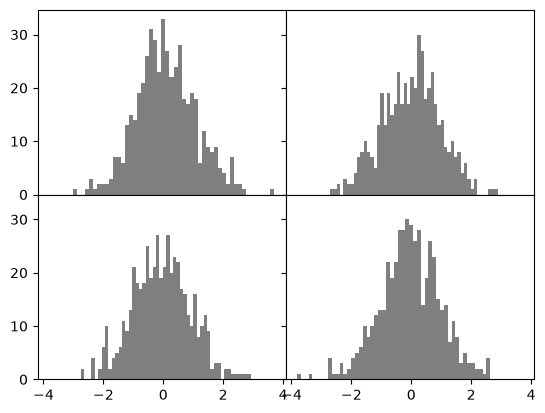

In [18]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)

for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.standard_normal(500), bins=50, color='black', alpha=0.5)

fig.subplots_adjust(wspace=0, hspace=0)

Você pode notar que os rótulos dos eixos se sobrepõem. O `matplotlib` não verifica se os rótulos se sobrepõem, então, em um caso como este, você precisaria corrigir os rótulos manualmente, especificando as posições e os rótulos das marcas de escala (veremos como fazer isso depois).

### 1.4. Cores, Marcadores e Estilos de Linha

A função de plotagem de linhas (`plot`) do `matplotlib` aceita arrays de coordenadas x e y e opções opcionais de estilo de cor. Por exemplo, para plotar x versus y com traços verdes, você executaria:

```python
ax.plot(x, y, linestyle="--" , color="green")
```

Vários nomes de cores são fornecidos para cores comumente usadas, mas você pode usar qualquer cor do espectro especificando seu código hexadecimal (por exemplo, `"#CECECE"`). Você pode ver alguns dos estilos de linha suportados consultando a docstring de `plt.plot`.

Os gráficos de linha também podem ter marcadores para destacar os pontos de dados reais. Como a função `plot` do `matplotlib` cria um gráfico de linha contínuo, interpolando entre os pontos, às vezes pode não ficar claro onde os pontos estão localizados. O marcador pode ser fornecido como uma opção de estilo adicional:

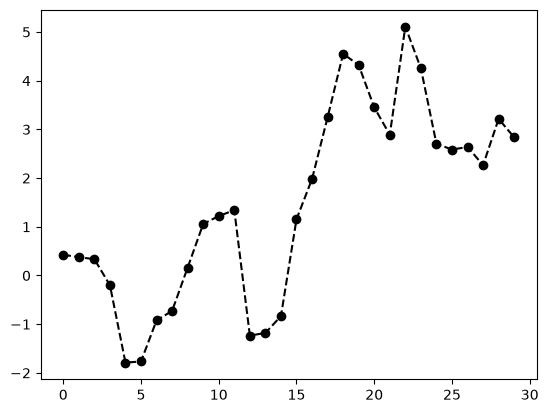

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(np.random.standard_normal(30).cumsum(), color='black', linestyle='dashed', marker='o');

Em gráficos de linhas, você notará que os pontos subsequentes são interpolados linearmente por padrão. Isso pode ser alterado com a opção `drawstyle`:

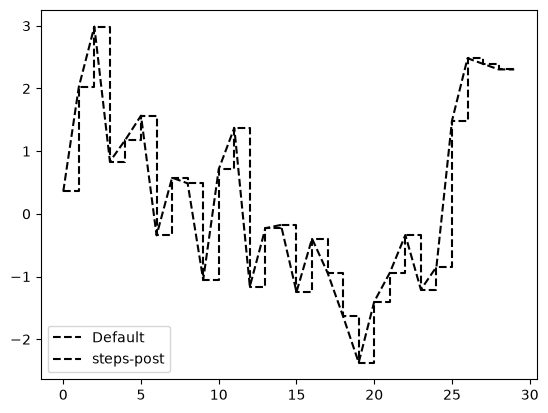

In [3]:
fig = plt.figure()
ax = fig.add_subplot()
data = np.random.standard_normal(30).cumsum()
ax.plot(data, color='black', linestyle='dashed', label='Default')
ax.plot(data, color='black', linestyle='dashed', drawstyle='steps-post', label='steps-post')
ax.legend();

Aqui, como passamos os argumentos de `label` para o `plot`, podemos criar uma legenda para identificar cada linha usando `ax.legend`.

### 1.5. Ticks, Rótulos e Legendas

A maioria dos tipos de decoração de gráficos pode ser acessada por meio de métodos em objetos `axes` do `matplotlib`. Isso inclui métodos como `xlim`, `xticks` e `xticklabels`. Esses métodos controlam, respectivamente, o intervalo do gráfico, a posição das marcas de escala e os rótulos das marcas. Eles podem ser usados ​​de duas maneiras:

- Chamado sem argumentos, retorna o valor do parâmetro atual (por exemplo, `ax.xlim()` retorna o intervalo atual do eixo `x`).

- Chamado com parâmetros, define o valor do parâmetro (por exemplo, `ax.xlim([0, 10])` define o intervalo do eixo `x` de `0` a `10`).

Todos esses métodos atuam no `AxesSubplot` ativo ou no `AxesSubplot` criado mais recentemente. Cada um corresponde a dois métodos no próprio objeto subplot; no caso de `xlim`, esses métodos são `ax.get_xlim` e `ax.set_xlim`.

Para ilustrar a personalização dos eixos, criamos uma figura e um gráfico simples de uma caminhada aleatória:

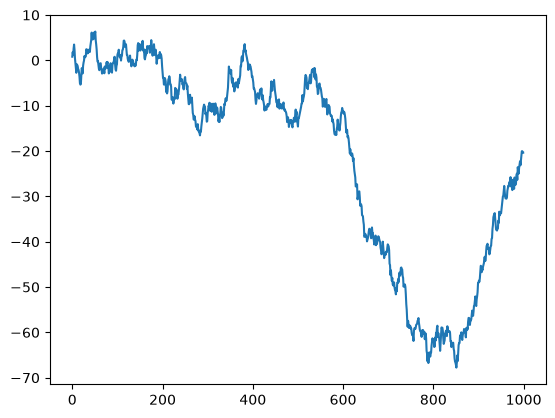

In [4]:
fig, ax = plt.subplots()

ax.plot(np.random.standard_normal(1000).cumsum());

Para alterar as marcas do eixo `x`, a maneira mais fácil é usar `set_xticks` e `set_xticklabels`. O primeiro instrui `matplotlib` sobre onde posicionar as marcas ao longo do intervalo de dados; por padrão, essas localizações também serão os rótulos. Mas podemos definir quaisquer outros valores como rótulos usando `set_xticklabels`.

In [5]:
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'], rotation=30, fontsize=8)

A opção de rotação define os rótulos das marcas de escala do eixo x com uma rotação de `30` graus. Por fim, `set_xlabel` atribui um nome ao eixo `x` e `set_title` define o título do subgráfico.

In [6]:
ax.set_xlabel('Stages')
ax.set_title('My first matplotlib plot')

Text(0.5, 1.0, 'My first matplotlib plot')

Colocando tudo junto para exibir o resultado:

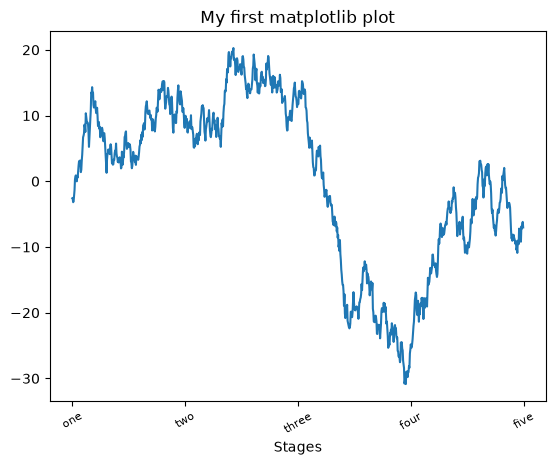

In [9]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())
ax.set_xlabel('Stages')
ax.set_title('My first matplotlib plot')
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'], rotation=30, fontsize=8)

Modificar o eixo `y` consiste no mesmo processo, substituindo `y` por `x` neste exemplo. A classe `axes` possui um método `set` que permite a configuração em lote das propriedades do gráfico. No exemplo anterior, também poderíamos ter escrito:

```python
ax.set(title="My first matplotlib plot", xlabel="Stages")
```

As legendas são outro elemento crucial para identificar os elementos do gráfico. Existem algumas maneiras de adicionar uma. A mais fácil é passar o argumento `label` ao adicionar cada parte do gráfico:

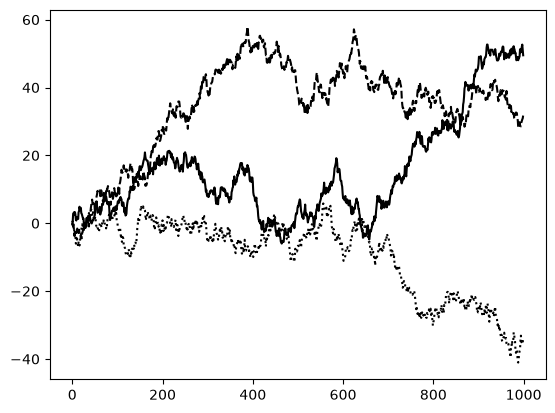

In [10]:
fig, ax = plt.subplots()

ax.plot(np.random.randn(1000).cumsum(), color='black', label='one')
ax.plot(np.random.randn(1000).cumsum(), color='black', linestyle='dashed', label='two')
ax.plot(np.random.randn(1000).cumsum(), color='black', linestyle='dotted', label='three');

Depois de fazer isso, você pode chamar `ax.legend()` para criar automaticamente uma legenda.

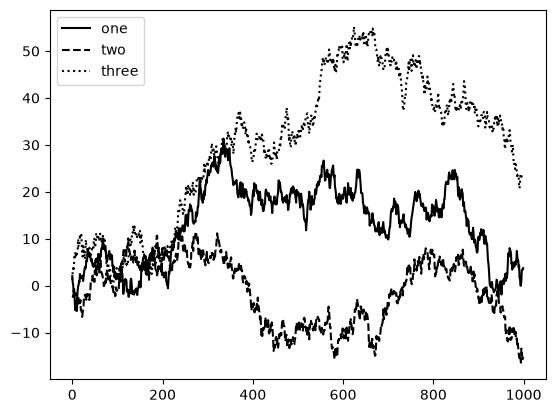

In [11]:
fig, ax = plt.subplots()

ax.plot(np.random.randn(1000).cumsum(), color='black', label='one')
ax.plot(np.random.randn(1000).cumsum(), color='black', linestyle='dashed', label='two')
ax.plot(np.random.randn(1000).cumsum(), color='black', linestyle='dotted', label='three')
ax.legend();

O método `legend` possui diversas outras opções para o argumento `loc`. Consulte a documentação oficial para obter mais informações.

A opção `loc` da legenda indica ao `matplotlib` onde posicionar o gráfico. O padrão é `"best"`, que tenta escolher um local o mais discreto possível. Para excluir um ou mais elementos da legenda, passe `no label` ou `label="_nolegend_"`.

### 1.6. Anotações e Desenhos em um Subplot

Além dos tipos de gráficos padrão, você pode adicionar suas próprias anotações, que podem incluir texto, setas ou outras formas. Você pode adicionar anotações e texto usando as funções `text`, `arrow` e `annotate`. A função `text` desenha texto nas coordenadas `(x, y)` especificadas no gráfico, com a opção de personalização de estilos:

```python
ax.text(x, y, "Hello world!", family="monospace", fontsize=10)
```

As anotações podem desenhar tanto texto quanto setas, organizadas adequadamente. Como exemplo, vamos plotar o preço de fechamento do índice `S&P 500` desde 2007 (obtido do Yahoo! Finance) e anotá-lo com algumas das datas importantes da crise financeira de `2008-2009`. Você pode executar este exemplo de código em uma única célula de um notebook Jupyter.

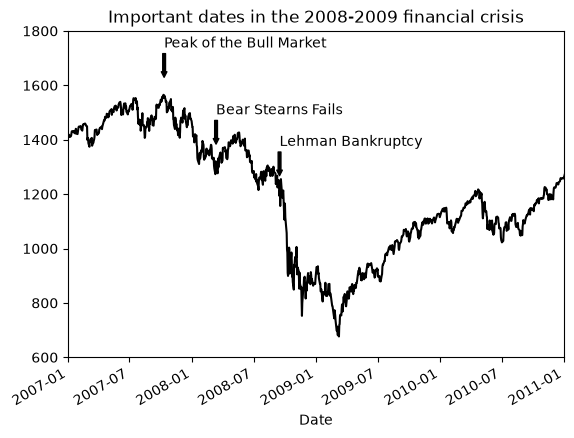

In [15]:
import pandas as pd
from datetime import datetime

fig, ax = plt.subplots()

data = pd.read_csv('./examples/spx.csv', index_col=0, parse_dates=True)
spx = data['SPX']
spx.plot(ax=ax, color='black')

crisis_data = [
    (datetime(2007, 10, 11), 'Peak of the Bull Market'),
    (datetime(2008, 3, 12), 'Bear Stearns Fails'),
    (datetime(2008, 9, 15), 'Lehman Bankruptcy')
]

for date, label in crisis_data:
    price = float(spx.asof(date))
    ax.annotate(label, xy=(date, price + 75),
                xytext=(date, price + 225),
                arrowprops=dict(facecolor='black', headwidth=4, width=2, headlength=4),
                horizontalalignment='left', verticalalignment='top')

# Zoom em 2007-2010
ax.set_xlim(['1/1/2007', '1/1/2011'])
ax.set_ylim([600, 1800])
ax.set_title('Important dates in the 2008-2009 financial crisis');

Há alguns pontos importantes a destacar neste gráfico. O método `ax.annotate` pode desenhar rótulos nas coordenadas `x` e `y` indicadas. Usamos os métodos `set_xlim` e `set_ylim` para definir manualmente os limites inicial e final do gráfico, em vez de usar os valores padrão do `matplotlib`. Por fim, `ax.set_title` adiciona um título principal ao gráfico.

Consulte a [galeria online do `matplotlib`](https://matplotlib.org/stable/gallery/index.html) para ver muitos outros exemplos de anotações dos quais você pode aprender.

Desenhar formas requer um pouco mais de cuidado. O `matplotlib` possui objetos que representam muitas formas comuns, chamados de *patches*. Alguns deles, como `Rectangle` e `Circle`, são encontrados em `matplotlib.pyplot`, mas o conjunto completo está localizado em `matplotlib.patches`.

Para adicionar uma forma a um gráfico, você cria o objeto patch e o adiciona a um subplot `ax` passando o patch para `ax.add_patch`:

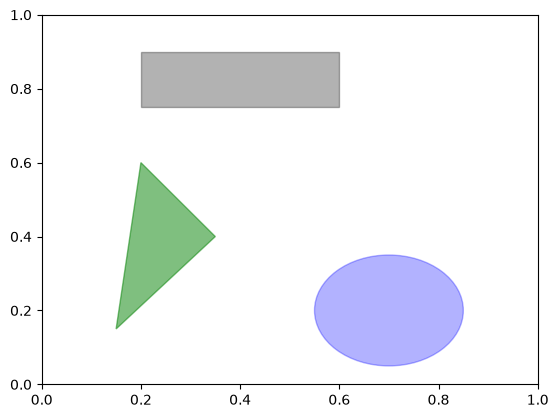

In [17]:
fig, ax = plt.subplots()

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='black', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color='blue', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]], color='green', alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon);

### 1.7. Salvando Gráficos em Arquivo

Você pode salvar a figura ativa em um arquivo usando o método de instância `savefig` do objeto `figure`. Por exemplo, para salvar uma versão SVG de uma figura, basta digitar:

```python
fig.savefig("figpath.svg")
```

O tipo de arquivo é inferido da extensão. Portanto, se você usar `.pdf`, obterá um PDF. Uma opção importante que uso frequentemente para publicar gráficos é `dpi`, que controla a resolução em pontos por polegada (`dpi`). Para obter o mesmo gráfico em `PNG` com `400 DPI`,` você faria:

```python
fig.savefig("figpath.png", dpi=400)
```

Veja a tabela abaixo para obter uma lista de outras opções para `savefig`.

| Argumento | Descrição |
|------------|------------|
| `fname` | String contendo o caminho do arquivo ou um objeto de arquivo do Python. O formato da figura é inferido a partir da extensão do arquivo (por exemplo, `.pdf` para PDF ou `.png` para PNG). |
| `dpi` | Resolução da figura em pontos por polegada (dots per inch). O padrão é 100 no IPython ou 72 no Jupyter, mas pode ser configurado. |
| `facecolor`, `edgecolor` | Define a cor de fundo da figura (fora dos subgráficos); o padrão é `"w"` (branco). |
| `format` | Formato explícito do arquivo a ser usado (`"png"`, `"pdf"`, `"svg"`, `"ps"`, `"eps"`, ...). |

### 1.8. Configuração do Matplotlib

O `matplotlib` vem configurado com esquemas de cores e valores padrão voltados principalmente para a preparação de figuras para publicação. Felizmente, quase todo o comportamento padrão pode ser personalizado por meio de parâmetros globais que controlam o tamanho da figura, o espaçamento entre subplots, as cores, os tamanhos das fontes, os estilos de grade e assim por diante. Uma maneira de modificar a configuração programaticamente em Python é usar o método `rc`; por exemplo, para definir o tamanho padrão global da figura como 10 × 10, você pode inserir:

```python
plt.rc("figure", figsize=(10, 10))
```

Todas as configurações atuais são encontradas no dicionário `plt.rcParams` e podem ser restauradas aos seus valores padrão chamando a função `plt.rcdefaults()`.

O primeiro argumento de `rc` é o componente que você deseja personalizar, como `"figure"`, `"axes"`, `"xtick"`, `"ytick"`, `"grid"`, `"legend"` ou muitos outros. Em seguida, pode-se inserir uma sequência de argumentos nomeados indicando os novos parâmetros. Uma maneira prática de anotar as opções do seu programa é usando um dicionário:

```python
plt.rc("font", family="monospace", weight="bold", size=8)
```

Para uma personalização mais completa e para ver uma lista de todas as opções, o `matplotlib` inclui um arquivo de configuração chamado `matplotlibrc` no diretório `matplotlib/mpl-data`. Se você personalizar este arquivo e colocá-lo no seu diretório pessoal com o nome `.matplotlibrc`, ele será carregado sempre que você usar o `matplotlib`.

## 2. Plotando com Pandas e Seaborn

### 2.1. Visão Geral

O `matplotlib` pode ser uma ferramenta de baixo nível. Você monta um gráfico a partir de seus componentes básicos: a exibição dos dados (ou seja, o tipo de gráfico: linha, barra, caixa, dispersão, contorno, etc.), legenda, título, rótulos de escala e outras anotações.

No Pandas, podemos ter várias colunas de dados, juntamente com rótulos de linha e coluna. O próprio Pandas possui métodos integrados que simplificam a criação de visualizações a partir de objetos `DataFrame` e `Series`. Outra biblioteca é o `seaborn`, uma biblioteca de gráficos estatísticos de alto nível construída sobre o `matplotlib`. O `seaborn` simplifica a criação de muitos tipos comuns de visualização.

`seaborn` pode ser instalada usando o `pip` como segue: `uv pip install seaborn`

Usamos a seguinte convensão de importação para `seaborn`

In [37]:
import seaborn as sns

### 2.2. Gráficos de Linhas

`Series` e `DataFrame` possuem um atributo `plot` para criar alguns tipos básicos de gráficos. Por padrão, `plot()` cria gráficos de linha:

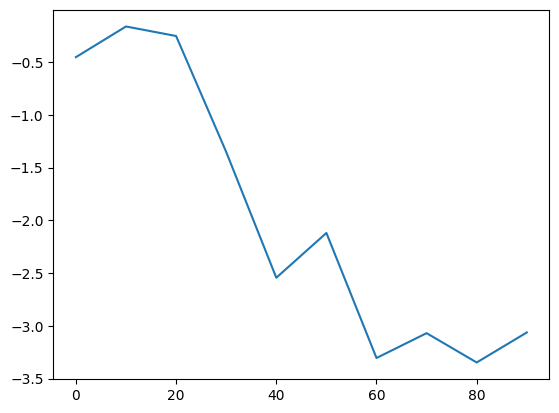

In [38]:
s = pd.Series(np.random.standard_normal(10).cumsum(), index=np.arange(0, 100, 10))
s.plot();

O índice do objeto `Series` é passado para o matplotlib para plotagem no eixo `x`, embora você possa desativar isso passando `use_index=False`. As marcas e os limites do eixo `x` podem ser ajustados com as opções `xticks` e `xlim`, e o eixo `y`, respectivamente, com `yticks` e `ylim`. Veja a tabela abaixo para uma lista parcial das opções de plotagem. Veremos mais algumas delas ao longo desta seção e deixaremos o restante para você explorar.

| Argumento | Descrição |
|------------|------------|
| `label` | Rótulo usado na legenda do gráfico. |
| `ax` | Objeto de subplot do Matplotlib onde o gráfico será desenhado; se não for informado, usa o subplot ativo. |
| `style` | String de estilo, como `"ko--"`, a ser passada para o Matplotlib. |
| `alpha` | Define a opacidade do preenchimento do gráfico (valor entre 0 e 1). |
| `kind` | Tipo de gráfico a ser criado: `"area"`, `"bar"`, `"barh"`, `"density"`, `"hist"`, `"kde"`, `"line"` ou `"pie"`; o padrão é `"line"`. |
| `figsize` | Tamanho do objeto da figura a ser criado. |
| `logx` | Define o eixo x em escala logarítmica; use `"sym"` para logaritmo simétrico que permite valores negativos. |
| `logy` | Define o eixo y em escala logarítmica; use `"sym"` para logaritmo simétrico que permite valores negativos. |
| `title` | Título do gráfico. |
| `use_index` | Usa o índice do objeto como rótulos dos eixos. |
| `rot` | Rotação dos rótulos dos eixos (de 0 a 360 graus). |
| `xticks` | Valores a serem usados como marcações no eixo x. |
| `yticks` | Valores a serem usados como marcações no eixo y. |
| `xlim` | Limites do eixo x (por exemplo, `[0, 10]`). |
| `ylim` | Limites do eixo y. |
| `grid` | Exibe a grade do gráfico; desativada por padrão. |

A maioria dos métodos de plotagem do Pandas aceita um parâmetro opcional `ax`, que pode ser um objeto `subplot` do `matplotlib`. Isso oferece maior flexibilidade no posicionamento de subplots em um layout de grade.

O método `plot` do `DataFrame` plota cada uma de suas colunas como uma linha diferente no mesmo subplot, criando uma legenda automaticamente.

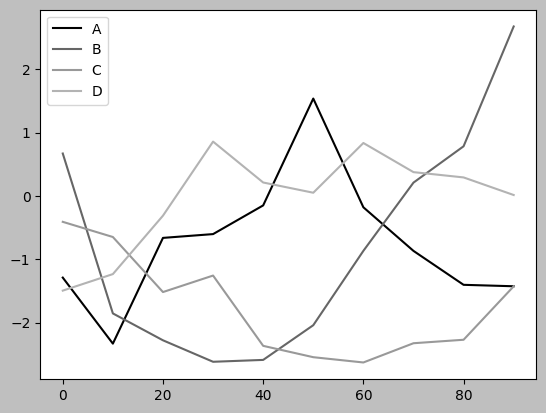

In [39]:
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0), 
                  columns=["A", "B", "C", "D"],
                  index=np.arange(0, 100, 10))
plt.style.use('grayscale')
df.plot();

>
> Aqui usamos `plt.style.use(grayscale)` para mudar para um esquema de cores mais adequado para publicação em preto e branco, já que alguns leitores não poderão ver os gráficos totalmente coloridos.
>

O atributo `plot` contém uma "família" de métodos para diferentes tipos de gráficos. Por exemplo, `df.plot()` é equivalente a `df.plot.line()`. Vamos explorar alguns desses métodos a seguir.


O `DataFrame` possui diversas opções que permitem certa flexibilidade no tratamento das colunas, por exemplo, a possibilidade de plotá-las todas no mesmo subplot ou criar subplots separados. Veja a tabela para mais detalhes.

| Argumento | Descrição |
|------------|------------|
| `subplots` | Plota cada coluna do `DataFrame` em um subplot separado. |
| `layout` | Tupla de 2 elementos `(linhas, colunas)` que define o layout dos subplots. |
| `sharex` | Se `subplots=True`, compartilha o mesmo eixo x entre os subplots, vinculando os limites e marcações. |
| `sharey` | Se `subplots=True`, compartilha o mesmo eixo y entre os subplots. |
| `legend` | Adiciona uma legenda ao subplot (`True` por padrão). |
| `sort_columns` | Plota as colunas em ordem alfabética; por padrão, usa a ordem original das colunas. |

### 2.3. Gráficos de Barras

As funções `plot.bar()` e `plot.barh()` criam gráficos de barras verticais e horizontais, respectivamente. Nesse caso, o índice da Série ou do DataFrame será usado como as marcas de escala do eixo `x` (barra) ou do eixo `y` (barra horizontal):

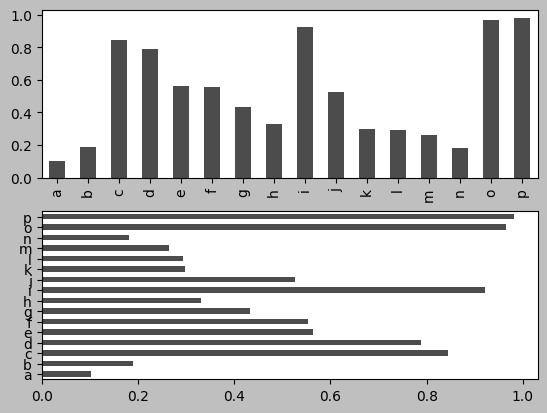

In [40]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))
data.plot.bar(ax=axes[0], color="black", alpha=0.7);
data.plot.barh(ax=axes[1], color="black", alpha=0.7);

Com um `DataFrame`, os gráficos de barras agrupam os valores de cada linha em barras, lado a lado, para cada valor.

In [41]:
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=["one", "two", "three", "four", "five", "six"],
                  columns=pd.Index(["A", "B", "C", "D"], name="Genus"))
df

Genus,A,B,C,D
one,0.741828,0.322733,0.238635,0.949635
two,0.930533,0.505655,0.319540,0.254781
three,0.645438,0.001007,0.305037,0.930309
four,0.033776,0.007408,0.534196,0.883711
five,0.474479,0.534827,0.532581,0.970915
six,0.905059,0.218142,0.957814,0.436086


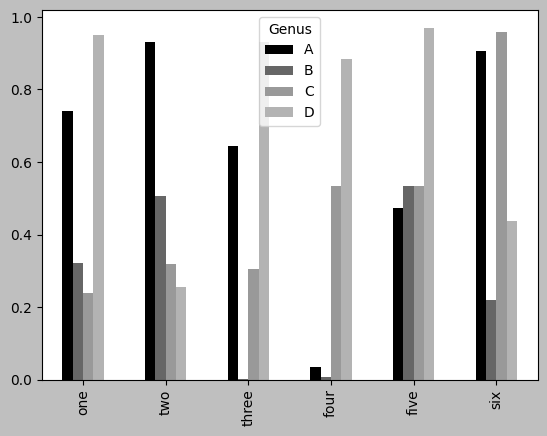

In [42]:
df.plot.bar();

Observe que o nome `"Genus"` nas colunas do `DataFrame` é usado como título da legenda.

Criamos gráficos de barras empilhadas a partir de um `DataFrame` passando `stacked=True`, o que resulta no empilhamento horizontal dos valores de cada linha.

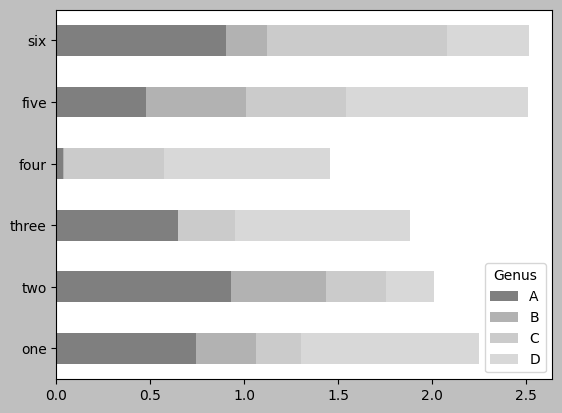

In [43]:
df.plot.barh(stacked=True, alpha=0.5);

>
> Nota! Uma receita útil para gráficos de barras é visualizar a frequência de valores de uma série
usando `value_counts`: `s.value_counts().plot.bar()`.
>

Vamos analisar um conjunto de dados de exemplo sobre gorjetas em restaurantes. Suponha que queiramos criar um gráfico de barras empilhadas mostrando a porcentagem de pontos de dados para cada tamanho de grupo em cada dia. Carregamos os dados usando `read_csv` e criamos uma tabela de contingência por dia e tamanho do grupo. A função `pandas.crosstab` é uma maneira conveniente de calcular uma tabela de frequência simples a partir de duas colunas de um `DataFrame`:

In [44]:
tips = pd.read_csv("/home/samuelmalves/Documents/Dev/Python/CTE-IA/prog-ciencia-de-dados/aulas/examples/tips.csv")
tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [45]:
party_counts = pd.crosstab(tips["day"], tips["size"])
party_counts = party_counts.reindex(index=["Thur", "Fri", "Sat", "Sun"])
party_counts

size,1,2,3,4,5,6
day,,,,,,
Thur,1,48,4,5,1,3
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1


Como não existem muitos grupos de uma ou seis pessoas, os removemos daqui:

In [46]:
party_counts = party_counts.loc[:, 2:5]

Em seguida, normalize para que a soma de cada linha seja igual a 1 e faça o gráfico:

In [47]:
party_pcts = party_counts.div(party_counts.sum(axis="columns"), axis="index")
party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


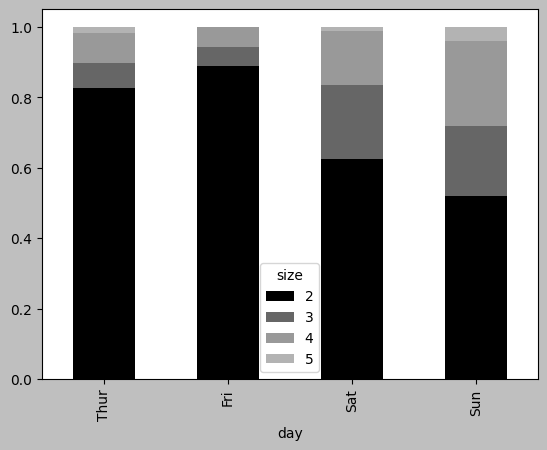

In [48]:
party_pcts.plot.bar(stacked=True);

Como você pode ver, o tamanho das festas parece aumentar nos fins de semana neste conjunto de dados.

Com dados que exigem agregação ou sumarização antes da criação de um gráfico, o uso do pacote `seaborn` pode simplificar bastante o processo. Vejamos agora a porcentagem de gorjetas por dia usando o `seaborn`:

In [49]:
import seaborn as sns
tips["tip_pct"] = tips["tip"] / (tips["total_bill"] - tips["tip"])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


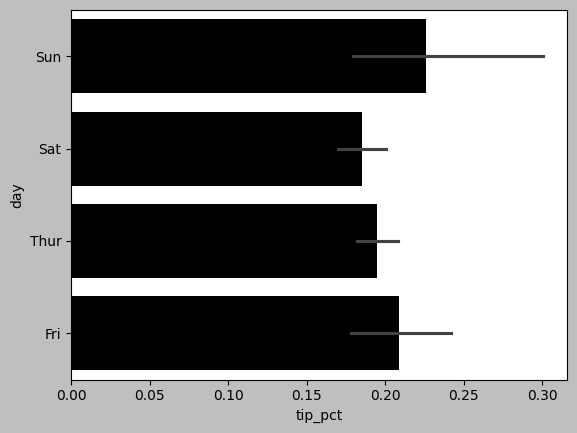

In [50]:
sns.barplot(x="tip_pct", y="day", data=tips, orient="h");

As funções de plotagem no `seaborn` recebem um argumento de dados, que pode ser um DataFrame do pandas. Os outros argumentos referem-se aos nomes das colunas. Como existem múltiplas observações para cada valor no dia, as barras representam o valor médio de tip_pct. As linhas pretas desenhadas nas barras representam o intervalo de confiança de `95%` (que pode ser configurado por meio de argumentos opcionais).

O `seaborn.barplot` possui uma opção de matiz que nos permite dividir por um valor categórico adicional.

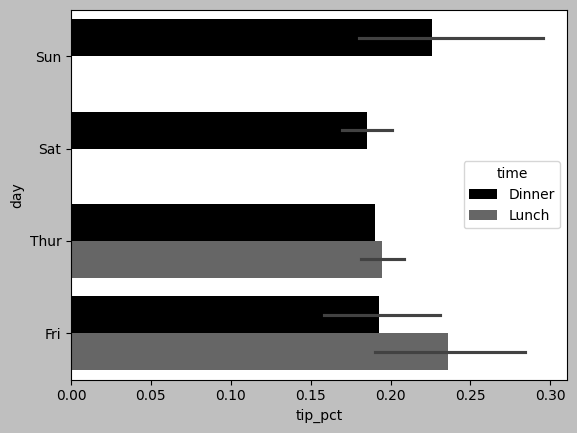

In [51]:
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h");

Observe que o seaborn alterou automaticamente a estética dos gráficos: a paleta de cores padrão, o fundo do gráfico e as cores das linhas da grade. Você pode alternar entre diferentes aparências de gráfico usando `seaborn.set_style`:

```python
sns.set_style("whitegrid")
````

Ao produzir gráficos para impressão em preto e branco, pode ser útil definir uma paleta de cores em tons de cinza, como esta:

```python
sns.set_palette("Greys_r")
```

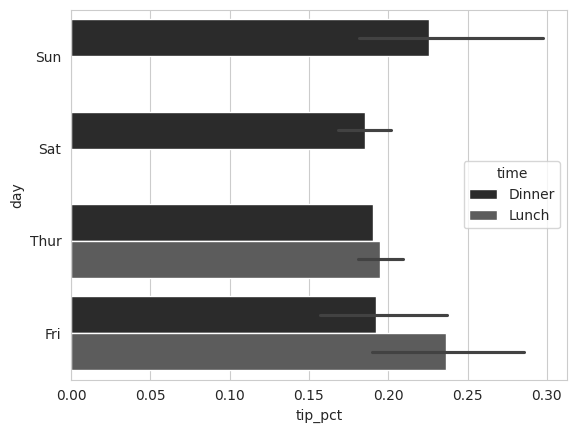

In [52]:
sns.set_style("whitegrid")
sns.set_palette("Greys_r")
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h");

### 2.4. Histogramas e Gráficos de Densidade

Um histograma é um tipo de gráfico de barras que exibe a frequência de valores de forma discreta. Os pontos de dados são divididos em intervalos discretos e uniformemente espaçados, e o número de pontos de dados em cada intervalo é plotado. Usando os dados de gorjeta (*tips*) anteriores, podemos criar um histograma das porcentagens de gorjeta em relação ao valor total da conta usando o método `plot.hist` da classe `Series`:

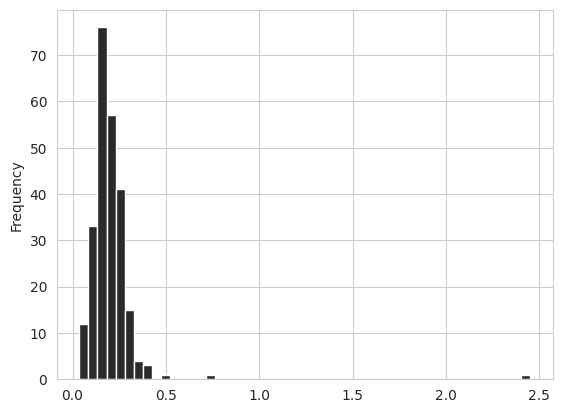

In [53]:
tips["tip_pct"].plot.hist(bins=50);

Um tipo de gráfico relacionado é o *gráfico de densidade*, que é formado calculando-se uma estimativa de uma distribuição de probabilidade contínua que pode ter gerado os dados observados. O procedimento usual é aproximar essa distribuição como uma mistura de `"kernels"` — isto é, distribuições mais simples como a distribuição normal. Assim, os gráficos de densidade também são conhecidos como gráficos de estimativa de densidade de kernel (`KDE`). Usando `plot.density`, cria-se um gráfico de densidade utilizando a estimativa convencional de mistura de normais:

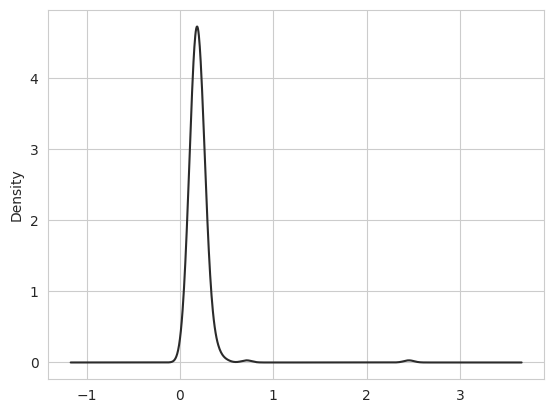

In [55]:
tips["tip_pct"].plot.density();

O `seaborn` facilita ainda mais a criação de histogramas e gráficos de densidade por meio do seu método `histplot`, que permite plotar simultaneamente um histograma e uma estimativa de densidade contínua. Como exemplo, considere uma distribuição bimodal composta por amostras de duas distribuições normais padrão diferentes:

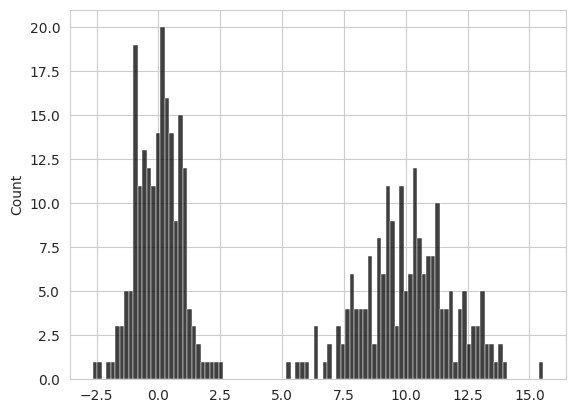

In [56]:
comp1 = np.random.standard_normal(200)
comp2 = 10 + 2 * np.random.standard_normal(200)
values = pd.Series(np.concatenate([comp1, comp2]))
sns.histplot(values, bins=100, color="black");

### 2.5. Gráficos de Dispersão ou de Pontos

Gráficos de pontos ou de dispersão podem ser uma maneira útil de examinar a relação entre duas séries de dados unidimensionais. Por exemplo, aqui carregamos o conjunto de dados `macrodata` do projeto `statsmodels`, selecionamos algumas variáveis ​​e, em seguida, calculamos as diferenças logarítmicas:

In [57]:
macro = pd.read_csv("/home/samuelmalves/Documents/Dev/Python/CTE-IA/prog-ciencia-de-dados/aulas/examples/macrodata.csv")
data = macro[["cpi", "m1", "tbilrate", "unemp"]]
trans_data = np.log(data).diff().dropna()
trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


Podemos então usar o método `regplot` do `seaborn`, que cria um gráfico de dispersão e ajusta uma linha de **regressão linear**:

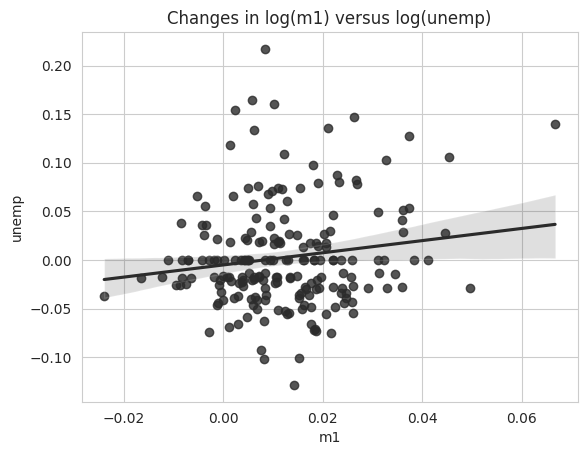

In [58]:
ax = sns.regplot(x="m1", y="unemp", data=trans_data)
ax.set_title("Changes in log(m1) versus log(unemp)");

Na análise exploratória de dados, é útil poder observar todos os diagramas de dispersão entre um grupo de variáveis; isso é conhecido como *gráfico de pares* ou *matriz de dispersão*. Criar um gráfico desse tipo do zero dá um pouco de trabalho, então o `seaborn` possui uma função prática de gráfico de pares que permite posicionar histogramas ou estimativas de densidade de cada variável ao longo da diagonal:

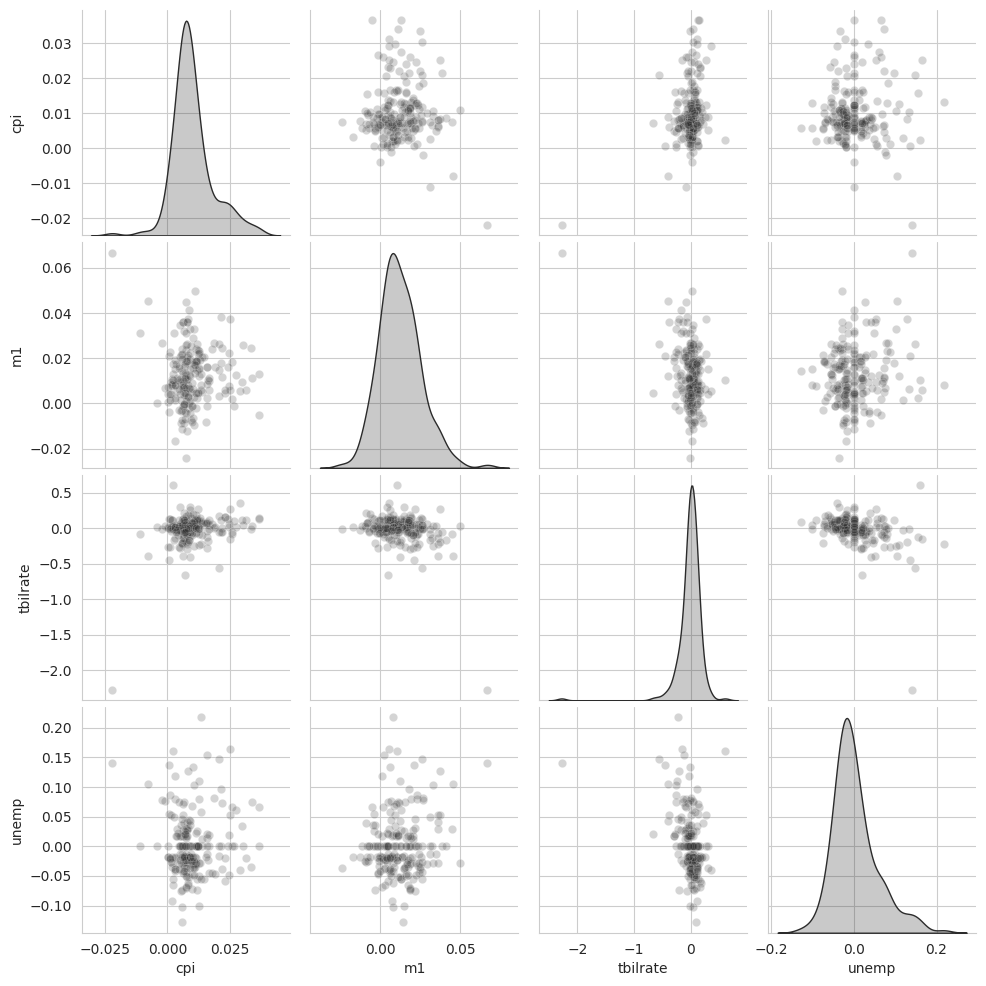

In [59]:
sns.pairplot(trans_data, diag_kind="kde", plot_kws={"alpha": 0.2});

Você pode notar o argumento `plot_kws`. Ele nos permite passar opções de configuração para as chamadas de plotagem individuais nos elementos fora da diagonal. Consulte a documentação do `seaborn.pairplot` para opções de configuração mais detalhadas.

### 2.6. Grades Facetadas e Dados Categóricos

E quanto aos conjuntos de dados com dimensões de agrupamento adicionais? Uma maneira de visualizar dados com muitas variáveis ​​categóricas é usar uma *grade facetada*, que é um layout bidimensional de gráficos onde os dados são divididos entre os gráficos em cada eixo com base nos valores distintos de uma determinada variável. O `seaborn` possui uma função integrada útil, `catplot`, que simplifica a criação de diversos tipos de gráficos facetados divididos por variáveis ​​categóricas:

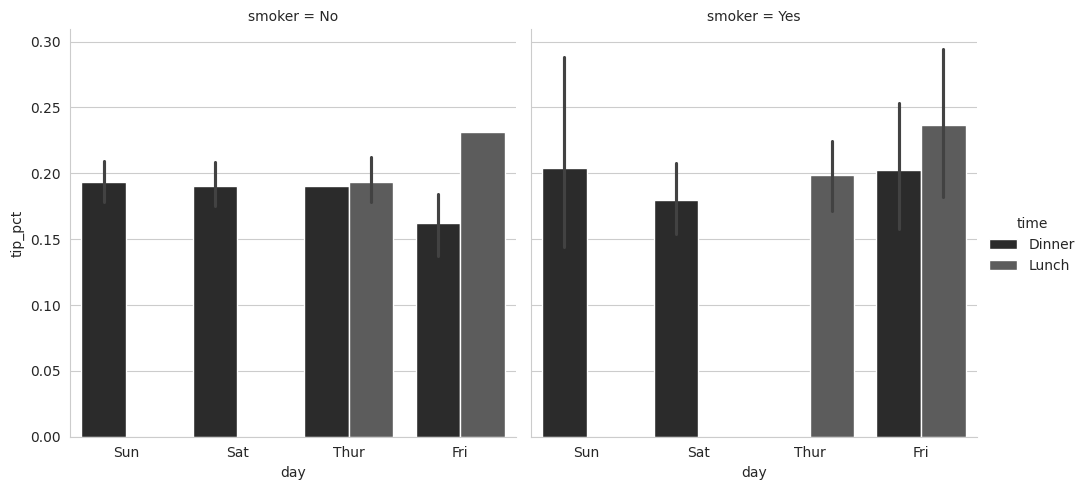

In [60]:
sns.catplot(x="day", y="tip_pct", hue="time", col="smoker", 
            kind="bar", data=tips[tips.tip_pct < 1]);

Em vez de agrupar por `time` usando diferentes cores de barra dentro de uma faceta, também podemos expandir a grade de facetas adicionando uma linha para cada valor de `time`:

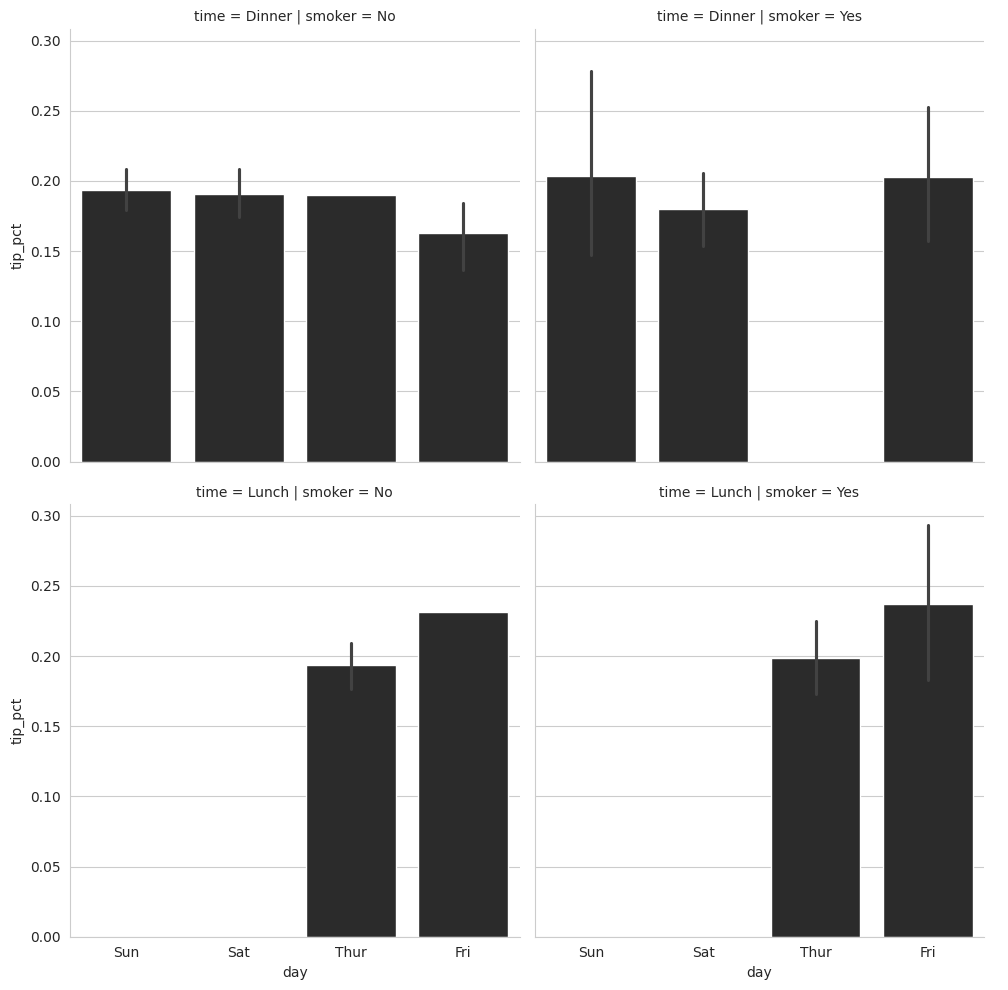

In [61]:
sns.catplot(x="day", y="tip_pct", row="time", col="smoker",
            kind="bar", data=tips[tips.tip_pct < 1]);

O `catplot` suporta outros tipos de gráficos que podem ser úteis dependendo do que você deseja exibir. Por exemplo, os diagramas de caixa (*box plots*), que mostram a mediana, os quartis e os valores discrepantes, podem ser um tipo de visualização eficaz:

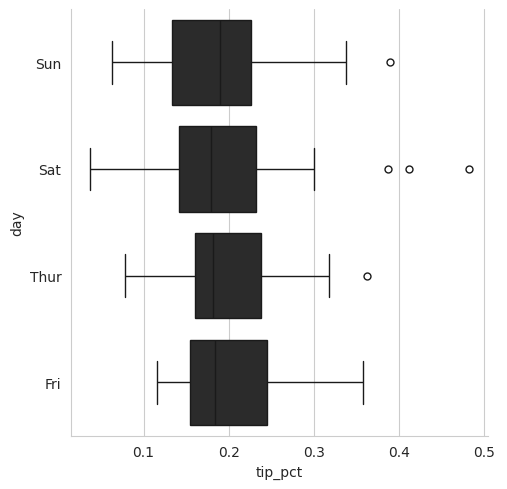

In [62]:
sns.catplot(x="tip_pct", y="day", kind="box", data=tips[tips.tip_pct < 0.5]);

Você pode criar seus próprios gráficos de grade facetada usando a classe mais geral `seaborn.FacetGrid`. Consulte a [documentação do `seaborn`](https://seaborn.pydata.org/) para obter mais informações.

## 3. Exercícios

In [63]:
# Esta célula informa ao Jupyter para fornecer informações detalhadas de depuração
# quando ocorrer um erro de execução. Execute-o antes de trabalhar nos exercícios.

%xmode Verbose

Exception reporting mode: Verbose


### Descrição dos Campos do Dataset

A tabela abaixo tras detalhes sobre os dataset de Bug-Fixing do Apache Hadoop [labeled-hadoop-bug-fix-dataset.csv](./datasets/bugfix/labeled-hadoop-bug-fix-dataset.csv):

| Field                     | From | Type       | Description                                                                                       |
|---------------------------|------|------------|---------------------------------------------------------------------------------------------------|
| Project                   | Jira | General    | The project to which the bug belongs                                                              |
| Owner                     | Jira | General    | The owner/maintainer of the project                                                               |
| Manager                   | Jira | General    | The committee responsible for the project                                                         |
| Category                  | Jira | General    | The project domain category                                                                       |
| Key                       | Jira | General    | A unique identifier for the bug                                                                   |
| Priority                  | Jira | General    | The importance of the issue in relation to other issues.                                          |
| Status                    | Jira | General    | The stage the bug is currently at in its lifecycle                                                |
| Reporter                  | Jira | General    | The person who entered the bug into the system                                                    |
| Assignee                  | Jira | General    | The person who was assigned to fix the bug                                                        |
| Components                | Jira | General    | The project component(s) to which the bug relates                                                 |
| SummaryTopWords           | Jira | Text       | 1000 top most frequent words of a brief one-line summary of the bug                               |
| DescriptionTopWords       | Jira | Text       | 1000 top most frequent words of a detailed description of the bug                                 |
| CommentTopWords           | Jira | Text       | 1000 top most frequent words of the comments of the bug                                           |
| CreationDate              | Jira | Time       | The date and time on which the bug was entered into Jira                                          |
| ResolutionDate            | Jira | Time       | The date and time on which the bug was resolved                                                   |
| LastUpdateDate            | Jira | Time       | The date and time on which the bug report was updated for the last time                           |
| AffectsVersions           | Jira | Versioning | The project version(s) for which the bug is (or was) manifesting                                  |
| FixVersions               | Jira | Versioning | The project version(s) in which the bug was (or will be) fixed                                    |
| NoComments                | Jira | Summation  | The number of all comments added in the bug                                                       |
| FirstCommentDate          | Jira | Time       | The date and time on which the first comment was added in the bug report                          |
| LastCommentDate           | Jira | Time       | The date and time on which the last comment was added in the bug report                           |
| NoWatchers                | Jira | Summation  | The number of how many people are watching (interested in) the bug                                |
| NoAttachments             | Jira | Summation  | The number of attachments (documents, images, screenshots) added in the bug report                |
| FirstAttachmentDate       | Jira | Time       | The date and time on which the first attachment was added                                         |
| LastAttachmentDate        | Jira | Time       | The date and time on which the last attachment was added                                          |
| NoAttachedPatches         | Jira | Summation  | The number of patches added to the bug                                                            |
| FirstAttachedPatchDate    | Jira | Time       | The date and time on which the first patch was attached                                           |
| LastAttachedPatchDate     | Jira | Time       | The date and time on which the last patch was attached                                            |
| NoInwardIssueLinks        | Jira | Link       | The issue on which the bug depends on (type: inwardIssue).                                        |
| OutwardIssueLinks         | Jira | Link       | The issue that depends on the bug (type: outwardIssue).                                           |
| HasMergeCommit            | Git  | General    | This field informs whether a bug fix had or not a merge commit                                    |
| CommitsMessagesTopWords   | Git  | Text       | 1000 top most frequent words of the commit messages related to the bug                            |
| NoCommits                 | Git  | Summation  | The number of commits related to the bug                                                          |
| NoAuthors                 | Git  | Summation  | The number of different authors who performed commits related to the bug                          |
| NoCommitters              | Git  | Summation  | The number of different committers who performed commits related to the bug                       |
| AuthorsFirstCommitDate    | Git  | Time       | The date and time on which the author performed the first commit to fix the bug                   |
| AuthorsLastCommitDate     | Git  | Time       | The date and time on which the author performed the last commit to fix the bug                    |
| CommittersFirstCommitDate | Git  | Time       | The date and time on which the committer performed the first commit to fix the bug                |
| CommittersLastCommitDate  | Git  | Time       | The date and time on which the committer performed the last commit to fix the bug                 |
| NoSrcAddFiles             | Git  | Summation  | The number of non-source code files added by commits related to the bug                           |
| NonSrcAddFiles            | Git  | SRC        | The number of non-source code files added by commits related to the bug                           |
| NonSrcDelFiles            | Git  | SRC        | The number of non-source code files deleted by commits related to the bug                         |
| NonSrcModFiles            | Git  | SRC        | The number of non-source code files modified by commits related to the bug                        |
| NonSrcAddLines            | Git  | SRC        | The number of non-source code lines added by commits related to the bug                           |
| NonSrcDelLines            | Git  | SRC        | The number of non-source code lines deleted by commits related to the bug                         |
| SrcAddFiles               | Git  | SRC        | The number of source code files added by commits related to the bug                               |
| SrcDelFiles               | Git  | SRC        | The number of source code files deleted by commits related to the bug                             |
| SrcModFiles               | Git  | SRC        | The number of source code files modified by commits related to the bug                            |
| SrcAddLines               | Git  | SRC        | The number of source code lines added by commits related to the bug                               |
| SrcDelLines               | Git  | SRC        | The number of deleted source code lines by commits related to the bug                             |
| TestAddFiles              | Git  | SRC        | The number of source code test files added by commits related to the bug                          |
| TestDelFiles              | Git  | SRC        | The number of source code test files deleted by commits related to the bug                        |
| TestModFiles              | Git  | SRC        | The number of source code test files modified by commits related to the bug                       |
| TestAddLines              | Git  | SRC        | The number of source code test lines added by commits related to the bug                          |
| TestDelLines              | Git  | SRC        | The number of source code test lines deleted by commits related to the bug                        |

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tema padrão
sns.set_theme(style="whitegrid")

# Carregar e preparar
bug_fix_dataset = pd.read_csv("/home/samuelmalves/Documents/Dev/Python/CTE-IA/prog-ciencia-de-dados/aulas/datasets/bugfix/labeled-hadoop-bug-fix-dataset.csv",
                              sep=";",
                              low_memory=False,
                              parse_dates=["CreationDate", "ResolutionDate"])

# Colunas numéricas úteis (coerção segura)
numeric_cols = ["NoComments","NoWatchers","NoAttachments","NoAttachedPatches",
            "NoCommits","NoAuthors","NoCommitters"]
for c in numeric_cols:
    bug_fix_dataset[c] = pd.to_numeric(bug_fix_dataset.get(c), errors="coerce")

# Duração em dias para análises de tempo de resolução BFT (bug fixing time)
bug_fix_dataset["BFT"] = (bug_fix_dataset["ResolutionDate"] - bug_fix_dataset["CreationDate"]).dt.total_seconds() / 86400.0
display(bug_fix_dataset.head())
display(bug_fix_dataset.info())

,Project,Owner,Manager,Category,Key,Priority,Status,Reporter,Assignee,Components,...,SrcModFiles,SrcAddLines,SrcDelLines,TestAddFiles,TestDelFiles,TestModFiles,TestAddLines,TestDelLines,Type,BFT
0,HADOOP,ASF,Apache Hadoop Committee,big-data,HADOOP-4975,Major,Closed,jly,jly,NaN,...,0,0,0,0,0,0,0,0,0.0,21.432188
1,HADOOP,ASF,Apache Hadoop Committee,big-data,HADOOP-4977,Blocker,Closed,matei,vivekr,NaN,...,0,0,0,0,0,0,0,0,0.0,12.152674
2,HADOOP,ASF,Apache Hadoop Committee,big-data,HADOOP-4985,Major,Closed,szetszwo,szetszwo,NaN,...,0,0,0,0,0,0,0,0,1.0,5.797164
3,HADOOP,ASF,Apache Hadoop Committee,big-data,HADOOP-4988,Blocker,Closed,vivekr,vivekr,NaN,...,0,0,0,0,0,0,0,0,0.0,8.542072
4,HADOOP,ASF,Apache Hadoop Committee,big-data,HADOOP-4997,Blocker,Closed,rangadi,rangadi,NaN,...,0,0,0,0,0,0,0,0,0.0,8.149583


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4516 entries, 0 to 4515
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   Project                    4516 non-null   object             
 1   Owner                      4516 non-null   object             
 2   Manager                    4516 non-null   object             
 3   Category                   4516 non-null   object             
 4   Key                        4516 non-null   object             
 5   Priority                   4516 non-null   object             
 6   Status                     4516 non-null   object             
 7   Reporter                   4516 non-null   object             
 8   Assignee                   4437 non-null   object             
 9   Components                 3129 non-null   object             
 10  SummaryTopWords            4465 non-null   object             
 11  Desc

None

### 3.1. Exercício

Linha temporal: criação de issues por mês

- Tarefa: Reamostrar por mês as criações (`CreationDate`) e plotar a série com `drawstyle="steps-post"` e marcadores, rotacionando os `ticks`.

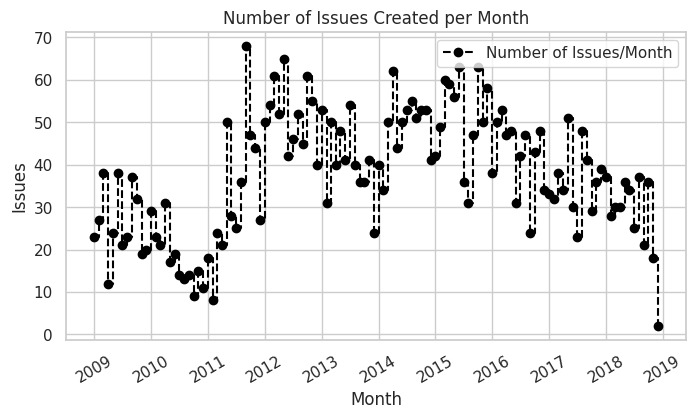

In [69]:
ts = bug_fix_dataset.set_index('CreationDate').resample('MS')['Key'].count()
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(ts.index, ts.values, color="black", linestyle="dashed", marker="o", drawstyle="steps-post", label="Number of Issues/Month")
ax.set_title("Number of Issues Created per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Issues")
ax.legend()
for label in ax.get_xticklabels():
    label.set_rotation(30)
plt.show()

### 3.2. Exercício

Subplots: distribuição de interações
- Tarefa: Criar uma grade `1x2` com histogramas de `NoComments` e `NoAttachments`, com `sharey`/`sharex` e transparência (`alpha`).

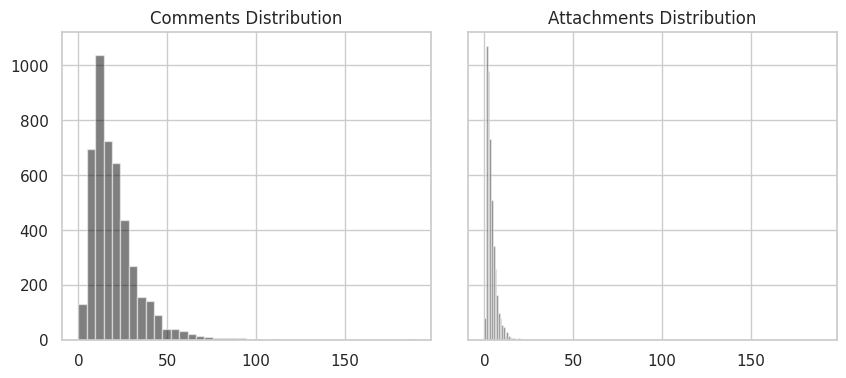

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, sharex=True)
axes[0].hist(bug_fix_dataset['NoComments'].dropna(), bins=40, color="black", alpha=0.5)
axes[0].set_title('Comments Distribution')
axes[1].hist(bug_fix_dataset['NoAttachments'].dropna(), bins=40, color="black", alpha=0.5)
axes[1].set_title('Attachments Distribution')
fig.subplots_adjust(wspace=0.1)

### 3.3. Exercício

Barras: contagem por prioridade
- Tarefa: Usar `plt.style.use("grayscale")` e plotar barras da contagem por `Priority`; adicionar rótulos rotacionados.

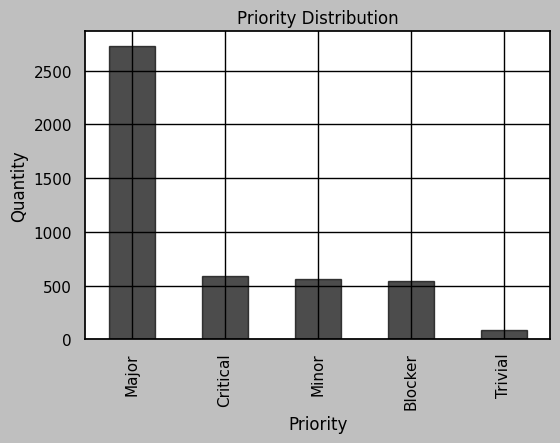

In [73]:
plt.style.use('grayscale')
priority_counts = bug_fix_dataset['Priority'].fillna('Unknown').value_counts()
ax = priority_counts.plot.bar(color='black', figsize=(6,4), alpha=0.7)
ax.set_title('Priority Distribution')
ax.set_xlabel('Priority')
ax.set_ylabel('Quantity')
plt.show()

### 3.4. Exercício

Barras empilhadas: Status dentro de Prioridade
- Tarefa: Criar `crosstab` `Priority x Status` e plotar empilhado normalizado (percentual). Adicionar legenda e grade.


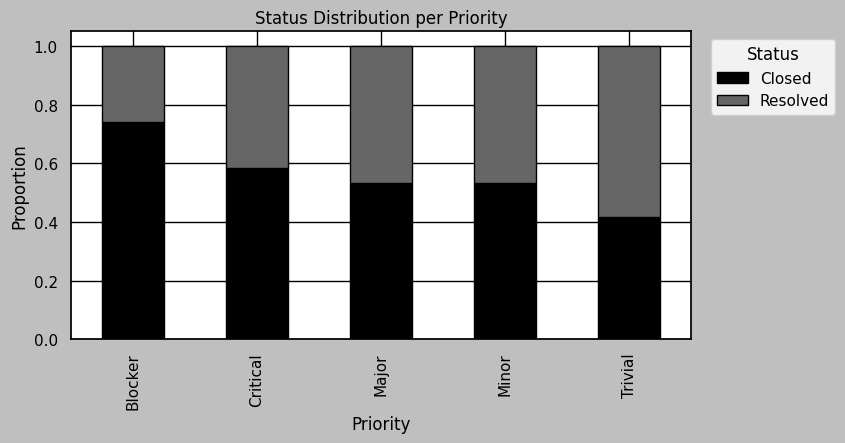

In [75]:
tab = pd.crosstab(bug_fix_dataset['Priority'].fillna('Unknown'), bug_fix_dataset['Status'].fillna('Unknown'), normalize='index')
ax = tab.plot.bar(stacked=True, figsize=(8,4))
ax.set_title('Status Distribution per Priority')
ax.set_ylabel('Proportion')
ax.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

### 3.5. Exercício

Histograma + KDE: tempo de resolução (*bug fixing time*)
- Tarefa: Plotar histograma de `BFT` (limite superior `p95` para retirar outliers) com densidade e KDE via `seaborn.histplot`.

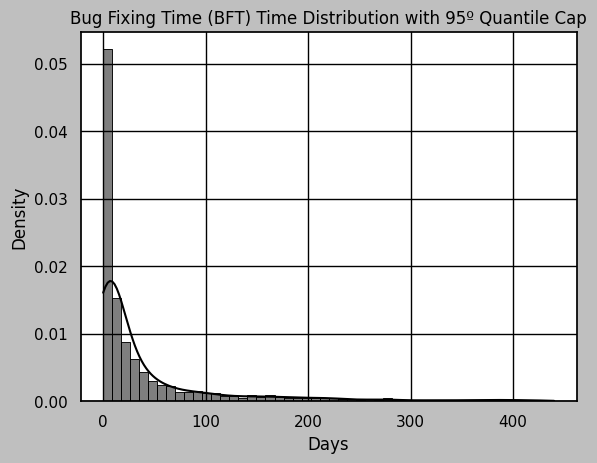

In [78]:
series = bug_fix_dataset['BFT'].dropna()
cap = series.quantile(0.95)
ax = sns.histplot(series[series <= cap], bins=50, color='black', kde=True, stat='density')
ax.set_title("Bug Fixing Time (BFT) Time Distribution with 95º Quantile Cap")
ax.set_xlabel('Days')
plt.show()

### 3.6. Exercício

Dispersão com regressão: atividade `x` tempo de resolução
- Tarefa: Fazer um regplot de `NoComments` vs `BFT` (filtrando `BFT > 0` e `<= p95`), e anotar os `3` maiores `outliers` com a coluna `Key`.

### 3.7. Exercício

Catplot facetado: média de resolução por tipo e prioridade
- Tarefa: Usar `seaborn.catplot(kind="bar")` para média de `BFT` por `Type` com `hue=Priority`; filtrar `BFT` positivas e recortar no `p95`.

### 3.8. Exercício

Pairplot: correlações entre contagens
- Tarefa: Construir um `pairplot` para ["NoComments","NoAttachments","NoCommits","NoAuthors","NoCommitters","BFT"] com `diag_kind="kde"` e `alph`a nos `scatter`.


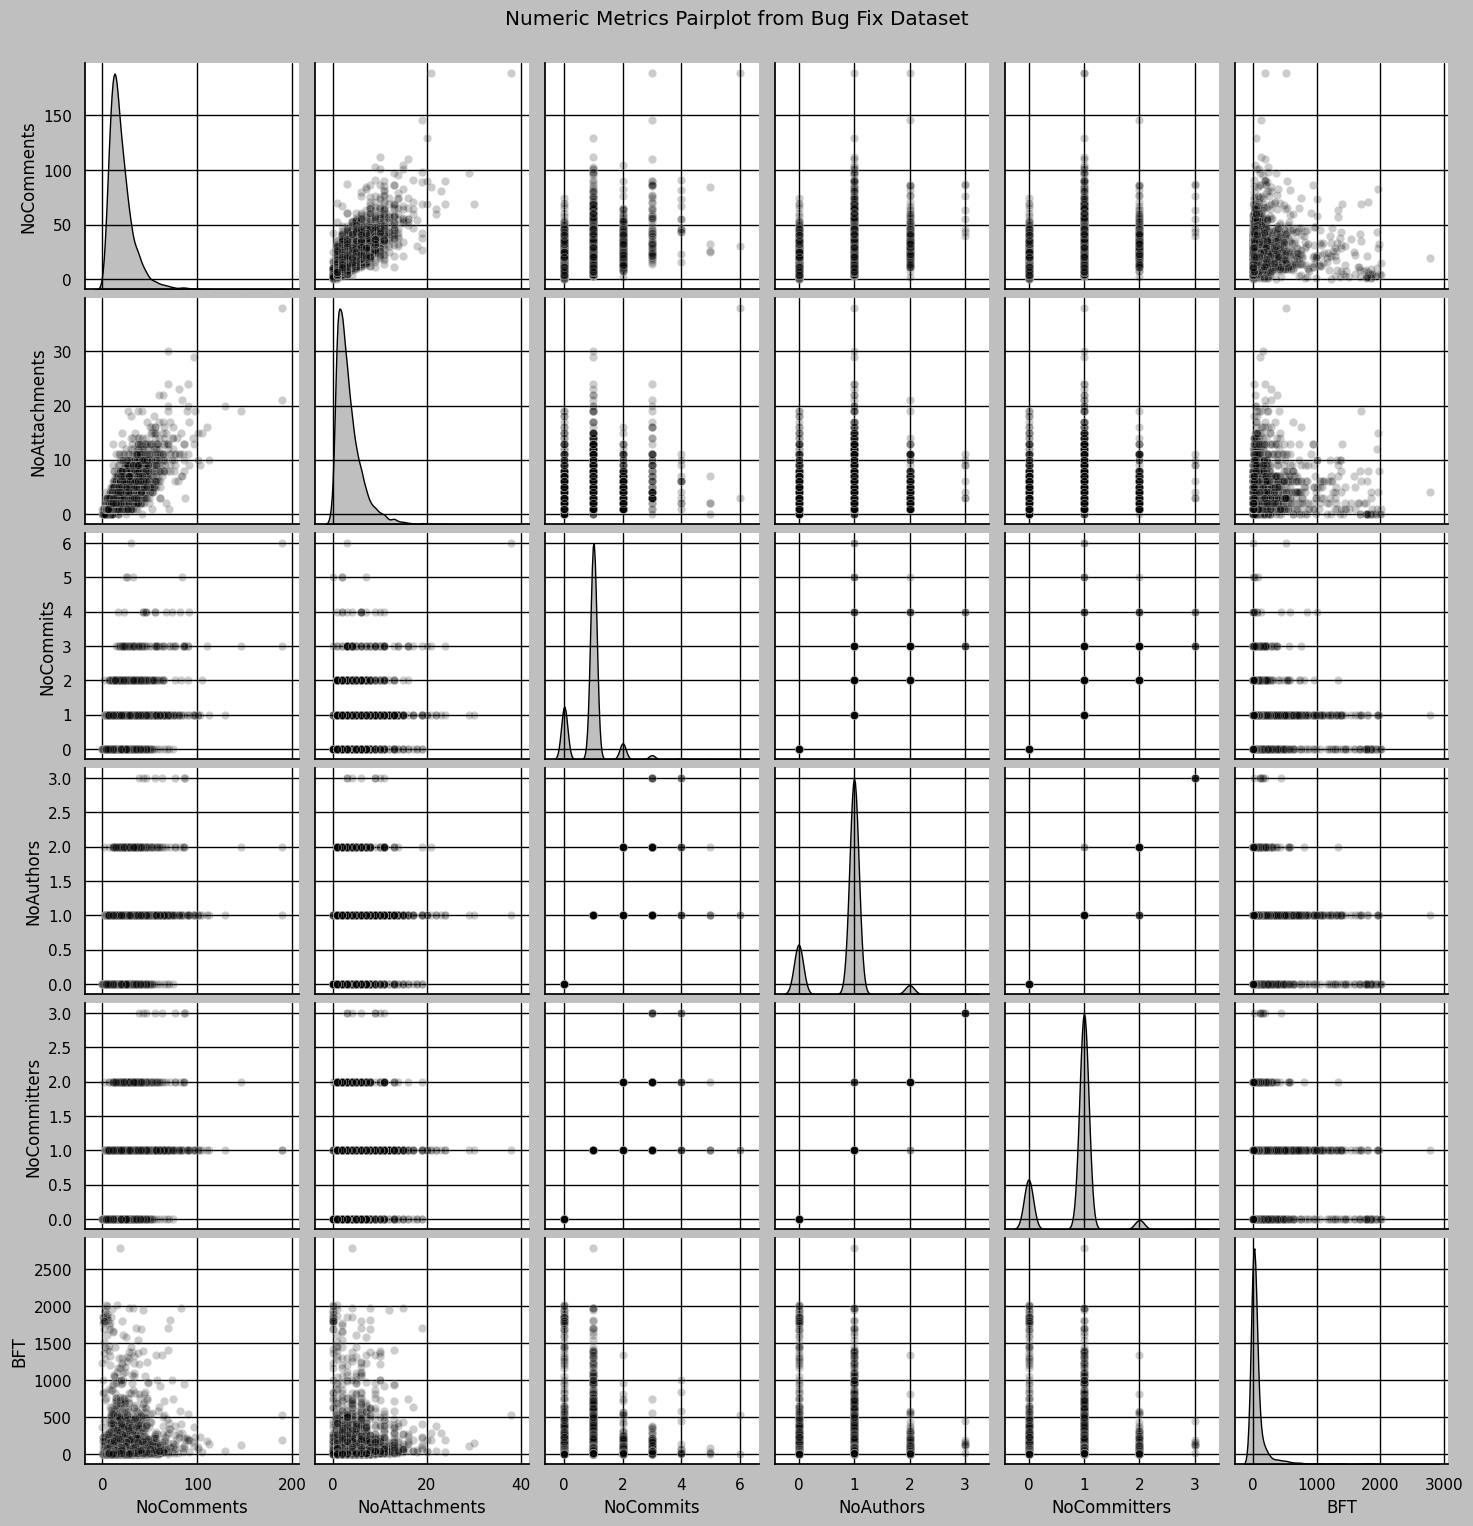

In [77]:
cols = ['NoComments', 'NoAttachments', 'NoCommits', 'NoAuthors', 'NoCommitters', 'BFT']
pp = sns.pairplot(bug_fix_dataset[cols].dropna(), diag_kind='kde', plot_kws={'alpha': 0.2, "color": "black"})
pp.figure.suptitle('Numeric Metrics Pairplot from Bug Fix Dataset', y=1.02)
plt.show()

### 3.9. Exercício

Linhas múltiplas + legenda e formatação de ticks
- Tarefa: Plotar, em um mesmo `Axes`, a contagem mensal de issues por `3` prioridades mais frequentes, cada uma com `linestyle` diferente; adicionar `legend(loc="best")` e rótulos legíveis.

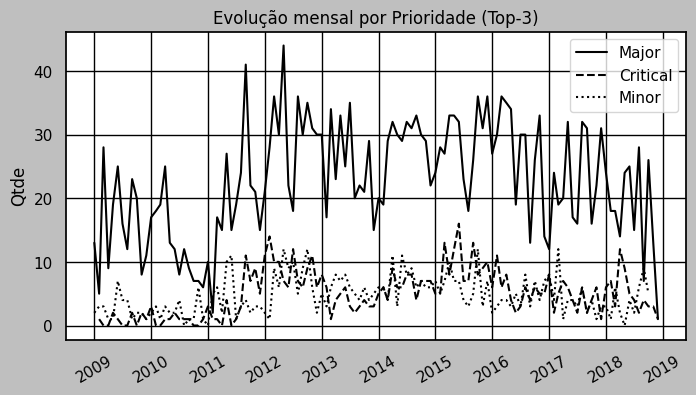

In [79]:
top_prio = bug_fix_dataset["Priority"].value_counts().head(3).index.tolist()
fig, ax = plt.subplots(figsize=(8,4))
linestyles = ["solid","dashed","dotted"]

for ls, p in zip(linestyles, top_prio):
    ts_p = (bug_fix_dataset.loc[bug_fix_dataset["Priority"]==p]
              .set_index("CreationDate")
              .resample("MS")["Key"].count())
    ax.plot(ts_p.index, ts_p.values, color="black", linestyle=ls, label=p)

ax.set_title("Evolução mensal por Prioridade (Top-3)")
ax.set_ylabel("Qtde")
ax.legend(loc="best")
for lbl in ax.get_xticklabels(): lbl.set_rotation(30)
plt.show()

### 3.10. Exercício

Layout, rcParams e exportação
- Tarefa: Ajustar `rcParams` para tamanho global da figura (`10x5`), criar `subplots` `1x2`: (a) barras de `Type`; (b) barras horizontais dos 10 principais `Assignees` por número de issues. Salvar como `PNG` em `./bugfix_summary.png` com `dpi=200`.